<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da15_datetime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DataFrame에서 날짜/시간(datetime) 타입 변수 다루기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SPX 주가 데이터셋

In [2]:
file_path = 'https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/examples/spx.csv'

In [3]:
spx = pd.read_csv(file_path)

In [4]:
spx.head()

,Date,SPX
0,1990-02-01 00:00:00,328.79
1,1990-02-02 00:00:00,330.92
2,1990-02-05 00:00:00,331.85
3,1990-02-06 00:00:00,329.66
4,1990-02-07 00:00:00,333.75


In [5]:
spx.tail()

,Date,SPX
5467,2011-10-10 00:00:00,1194.89
5468,2011-10-11 00:00:00,1195.54
5469,2011-10-12 00:00:00,1207.25
5470,2011-10-13 00:00:00,1203.66
5471,2011-10-14 00:00:00,1224.58


In [6]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5472 non-null   object 
 1   SPX     5472 non-null   float64
dtypes: float64(1), object(1)
memory usage: 85.6+ KB


## 문자열 타입의 컬럼을 datetime 타입으로 변환

In [7]:
spx.Date = pd.to_datetime(spx.Date)

In [8]:
spx.head()

,Date,SPX
0,1990-02-01,328.79
1,1990-02-02,330.92
2,1990-02-05,331.85
3,1990-02-06,329.66
4,1990-02-07,333.75


In [9]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


## csv 파일에서 데이터프레임을 생성할 때 날짜/시간 관련 파라미터 설정

In [10]:
spx = pd.read_csv(file_path,
                  parse_dates=['Date'],
                  date_format={'Date': '%Y-%m-%d %H:%M:%S'})

In [11]:
spx.head()

,Date,SPX
0,1990-02-01,328.79
1,1990-02-02,330.92
2,1990-02-05,331.85
3,1990-02-06,329.66
4,1990-02-07,333.75


In [12]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


# 기간별(연도별, 분기별, 월별, ...) 통계

날짜/시간(datetime) 타입의 컬럼을 인덱스로 만들고 분석.

In [13]:
spx_with_index = spx.set_index(keys='Date')
spx_with_index

,SPX
Date,
1990-02-01,328.79
1990-02-02,330.92
1990-02-05,331.85
1990-02-06,329.66
1990-02-07,333.75
...,...
2011-10-10,1194.89
2011-10-11,1195.54
2011-10-12,1207.25


In [14]:
spx_with_index.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5472 entries, 1990-02-01 to 2011-10-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPX     5472 non-null   float64
dtypes: float64(1)
memory usage: 85.5 KB


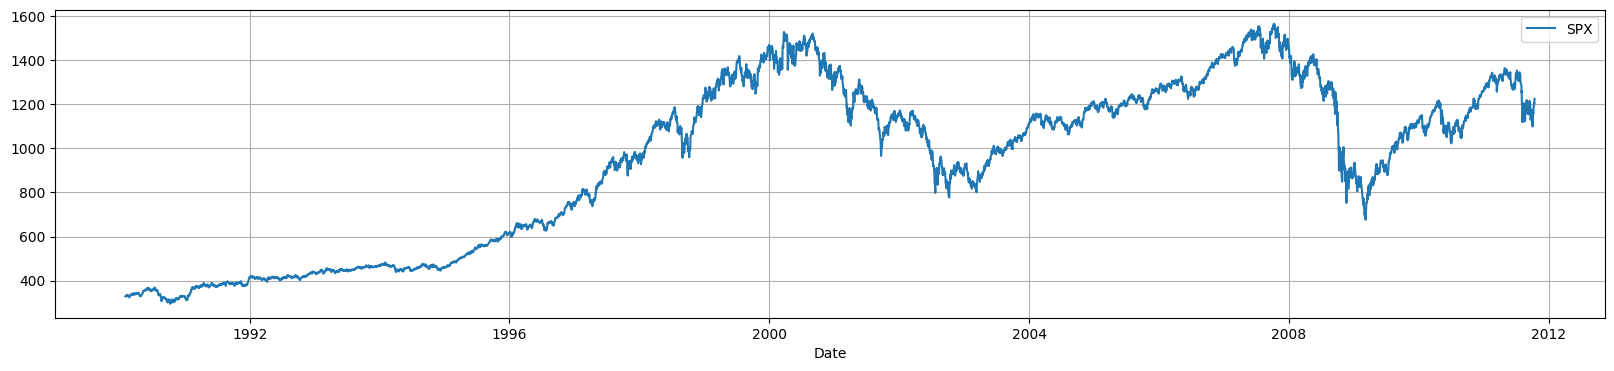

In [21]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=spx_with_index)
plt.grid()
plt.show()

## 연도별 주가 평균

In [22]:
spx_with_index.resample(rule='YS').mean()  # rule='YS': Year Start(시작일을 인덱스로)

,SPX
Date,
1990-01-01,334.123506
1991-01-01,376.186324
1992-01-01,415.747008
1993-01-01,451.614822
1994-01-01,460.416508
1995-01-01,541.719087
1996-01-01,670.494843
1997-01-01,873.427787
1998-01-01,1085.503254


In [17]:
spx_by_year = spx_with_index.resample(rule='YE').mean()  # rule='YE': Year End(종료일을 인덱스로)
spx_by_year

,SPX
Date,
1990-12-31,334.123506
1991-12-31,376.186324
1992-12-31,415.747008
1993-12-31,451.614822
1994-12-31,460.416508
1995-12-31,541.719087
1996-12-31,670.494843
1997-12-31,873.427787
1998-12-31,1085.503254


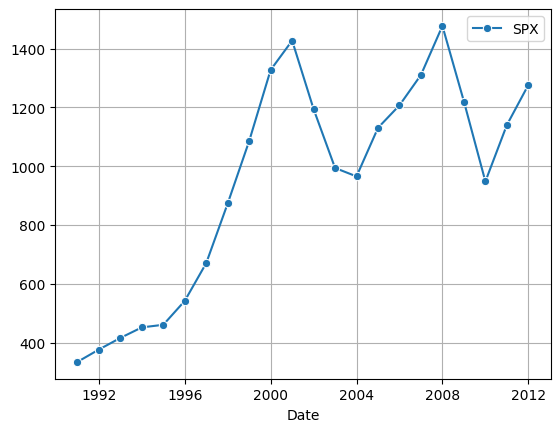

In [19]:
sns.lineplot(data=spx_by_year, marker='o')
plt.grid()
plt.show()

## 분기별 주가 평균

In [24]:
spx_by_quarter = spx_with_index.resample(rule='QE').mean()
spx_by_quarter

,SPX
Date,
1990-03-31,334.751951
1990-06-30,349.796508
1990-09-30,335.881746
1990-12-31,316.562031
1991-03-31,352.282951
...,...
2010-12-31,1204.585625
2011-03-31,1302.529032
2011-06-30,1318.332857


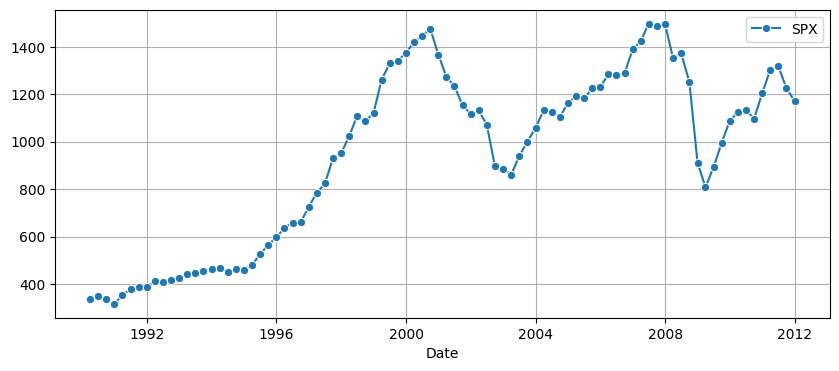

In [30]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=spx_by_quarter, marker='o')
plt.grid()
plt.show()

## 월별 주가 평균

In [33]:
spx_by_month = spx_with_index.resample(rule='ME').mean()
spx_by_month

,SPX
Date,
1990-02-28,330.452632
1990-03-31,338.465000
1990-04-30,338.178000
1990-05-31,350.250000
1990-06-30,360.386667
...,...
2011-06-30,1287.288636
2011-07-31,1325.184500
2011-08-31,1185.305652


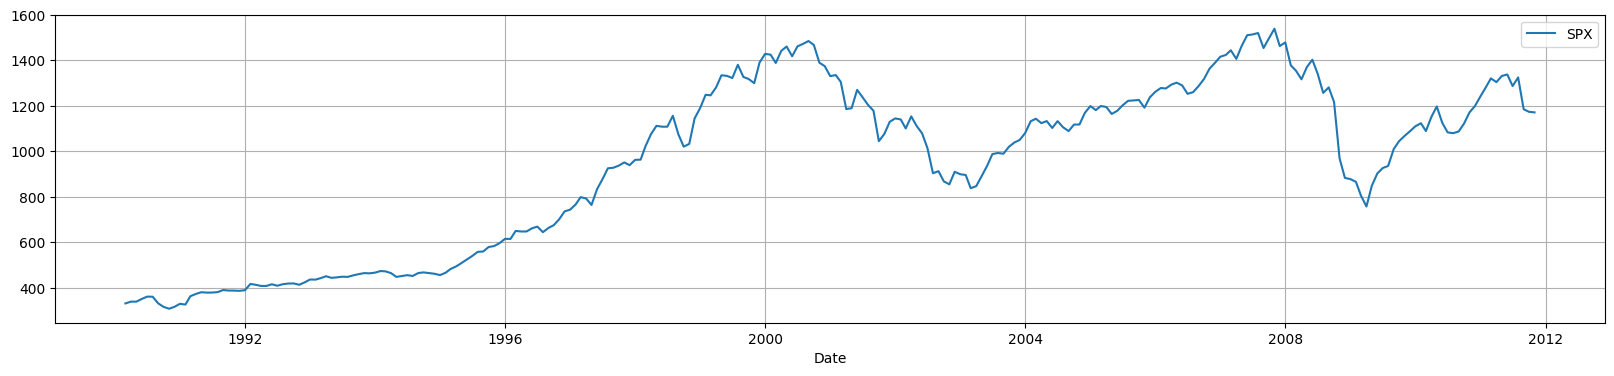

In [34]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=spx_by_month)
plt.grid()
plt.show()

# banklist 데이터셋

In [35]:
banklist_file = 'https://github.com/JakeOh/202605_BD57/raw/refs/heads/main/datasets/banklist.csv'

*   banklist.csv 파일을 읽고 데이터프레임 생성
    *   날짜/시간 타입으로 변환할 수 있는 변수(컬럼)들은 datetime 타입으로 변환.
*   연도별 파산한 은행 숫자 시각화
*   분기별 파산한 은행 숫자 시각화
*   월별 파산한 은행 숫자 시각화
*   파산한 날짜는 'Closing Date'로 사용.

In [36]:
banklist = pd.read_csv(banklist_file)
banklist

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,15-Dec-17,20-Dec-17
1,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,13-Oct-17,20-Oct-17
2,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
3,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
4,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,5-Dec-17
...,...,...,...,...,...,...,...
550,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,19-Aug-14
551,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,18-Nov-02
552,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,18-Feb-03
553,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,17-Mar-05


In [37]:
banklist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              555 non-null    object
 1   City                   555 non-null    object
 2   ST                     555 non-null    object
 3   CERT                   555 non-null    int64 
 4   Acquiring Institution  555 non-null    object
 5   Closing Date           555 non-null    object
 6   Updated Date           555 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.5+ KB


In [38]:
banklist = pd.read_csv(banklist_file,
                       parse_dates=['Closing Date', 'Updated Date'],
                       date_format='%d-%b-%y')
# date_format={'Closing Date': '%d-%b-%y', 'Updated Date': '%d-%b-%y'}
banklist

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,2017-12-15,2017-12-20
1,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,2017-10-13,2017-10-20
2,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-05-26,2017-07-26
3,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-05-05,2017-07-26
4,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-04-28,2017-12-05
...,...,...,...,...,...,...,...
550,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",2001-07-27,2014-08-19
551,Malta National Bank,Malta,OH,6629,North Valley Bank,2001-05-03,2002-11-18
552,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2001-02-02,2003-02-18
553,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,2000-12-14,2005-03-17


In [39]:
banklist_indexed = banklist.set_index(keys='Closing Date')
banklist_indexed

,Bank Name,City,ST,CERT,Acquiring Institution,Updated Date
Closing Date,,,,,,
2017-12-15,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,2017-12-20
2017-10-13,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,2017-10-20
2017-05-26,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-07-26
2017-05-05,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-07-26
2017-04-28,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-12-05
...,...,...,...,...,...,...
2001-07-27,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",2014-08-19
2001-05-03,Malta National Bank,Malta,OH,6629,North Valley Bank,2002-11-18
2001-02-02,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2003-02-18


In [40]:
banklist_indexed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 555 entries, 2017-12-15 to 2000-10-13
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              555 non-null    object        
 1   City                   555 non-null    object        
 2   ST                     555 non-null    object        
 3   CERT                   555 non-null    int64         
 4   Acquiring Institution  555 non-null    object        
 5   Updated Date           555 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 30.4+ KB


In [47]:
banklist_by_year = banklist_indexed.resample(rule='YS').size()
banklist_by_year

,0
Closing Date,
2000-01-01,2
2001-01-01,4
2002-01-01,11
2003-01-01,3
2004-01-01,4
2005-01-01,0
2006-01-01,0
2007-01-01,3
2008-01-01,25


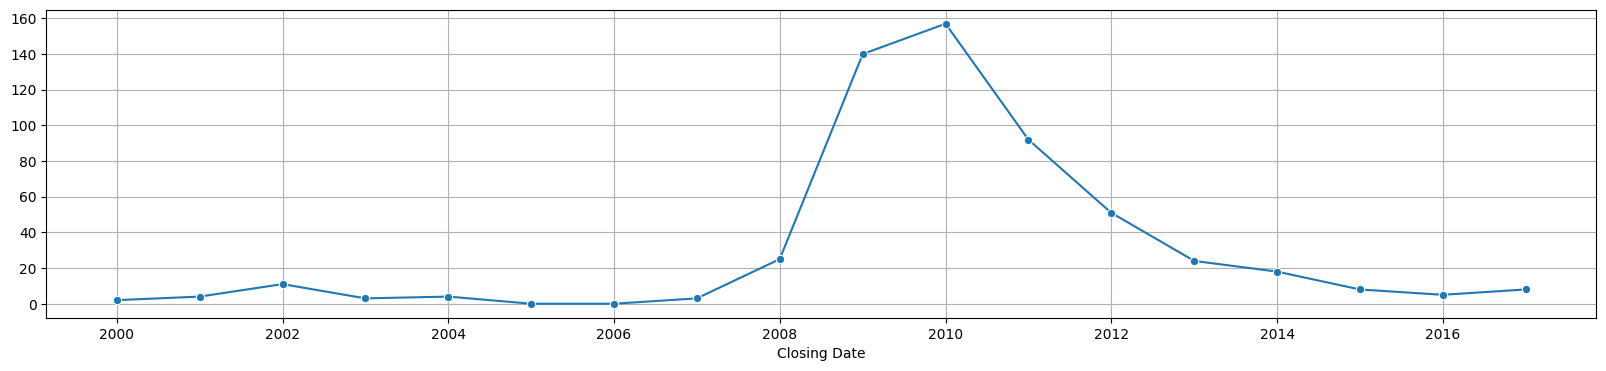

In [48]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=banklist_by_year, marker='o')
plt.grid()
plt.show()

In [49]:
def resample_lineplot(rule):
    df = banklist_indexed.resample(rule=rule).size()
    plt.figure(figsize=(20, 4))
    sns.lineplot(data=df)
    plt.grid()
    plt.show()

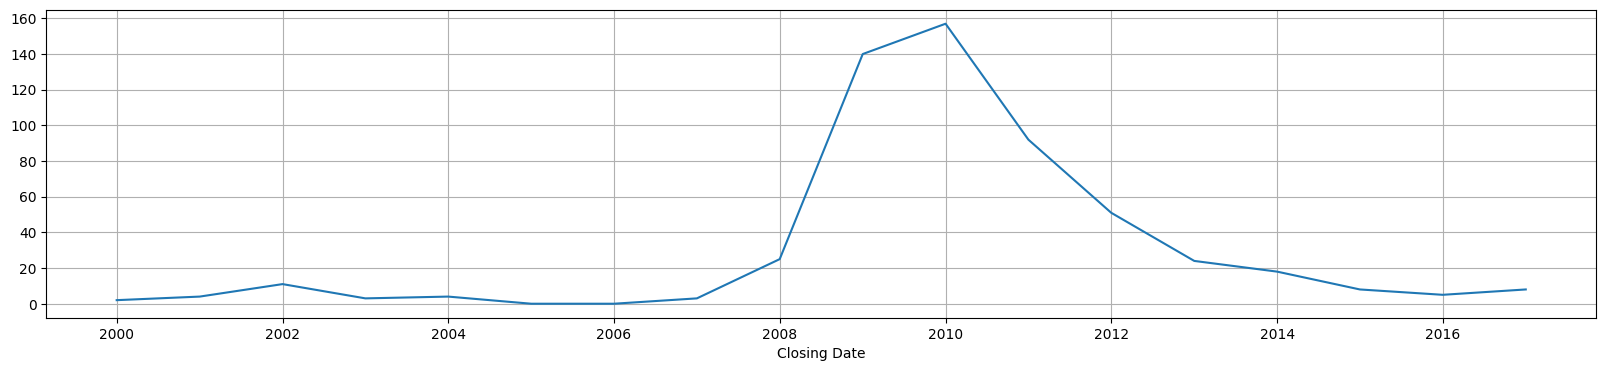

In [50]:
resample_lineplot(rule='YS')

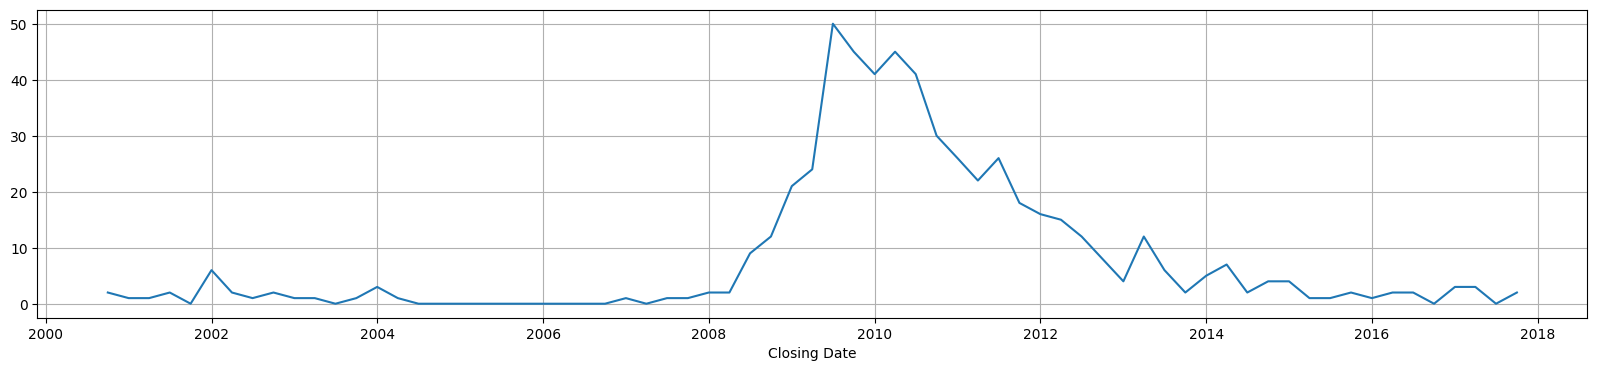

In [51]:
resample_lineplot(rule='QS')

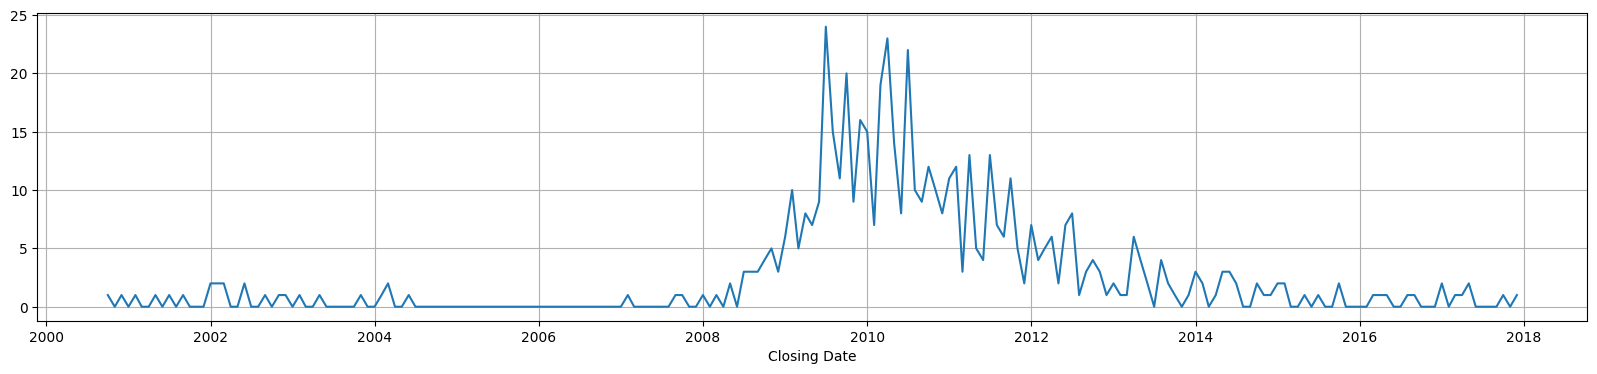

In [52]:
resample_lineplot(rule='MS')

In [61]:
# 중복된 은행 이름 찾기
banklist[banklist['Bank Name'].duplicated(keep=False)]
#> pandas.Series.duplicate() 메서드 keep 파라미터
#> keep='first': 기본값. 중복된 행들 중 첫번째 행은 제외하고 나머지 행들만 중복으로 True를 리턴.
#> keep='last': 중복된 행들 중 마지막 행은 제외하고 나머지 행들을 중복 행으로 취급해서 True를 리턴.
#> keep=False: 중복된 모든 행들을 True로 리턴.

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
15,Premier Bank,Denver,CO,34112,"United Fidelity Bank, fsb",2015-07-10,2016-08-17
28,Valley Bank,Fort Lauderdale,FL,21793,"Landmark Bank, National Association",2014-06-20,2017-10-06
29,Valley Bank,Moline,IL,10450,Great Southern Bank,2014-06-20,2015-06-26
59,Frontier Bank,LaGrange,GA,16431,HeritageBank of the South,2013-03-08,2017-11-13
99,Premier Bank,Wilmette,IL,35419,International Bank of Chicago,2012-03-23,2012-10-17
112,The First State Bank,Stockbridge,GA,19252,Hamilton State Bank,2012-01-20,2014-03-21
127,First State Bank,Cranford,NJ,58046,Northfield Bank,2011-10-14,2017-10-23
151,Summit Bank,Prescott,AZ,57442,The Foothills Bank,2011-07-15,2014-08-19
163,Summit Bank,Burlington,WA,513,Columbia State Bank,2011-05-20,2017-10-23
168,The Park Avenue Bank,Valdosta,GA,19797,Bank of the Ozarks,2011-04-29,2014-03-21


In [62]:
# 주별 연도별 파산한 은행 수
by_st_year = banklist_indexed.pivot_table(values='Bank Name',
                                          index=['ST', pd.Grouper(freq='YS')],
                                          aggfunc='count')
by_st_year

Bank Name
ST Closing Date           
AL 2009-01-01            3
   2010-01-01            1
   2011-01-01            2
   2012-01-01            1
AR 2001-01-01            1
...                    ...
WI 2013-01-01            2
   2016-01-01            1
   2017-01-01            1
WV 2008-01-01            1
WY 2009-01-01            1

[188 rows x 1 columns]

In [63]:
by_st_year.reset_index(inplace=True)
by_st_year

,ST,Closing Date,Bank Name
0,AL,2009-01-01,3
1,AL,2010-01-01,1
2,AL,2011-01-01,2
3,AL,2012-01-01,1
4,AR,2001-01-01,1
...,...,...,...
183,WI,2013-01-01,2
184,WI,2016-01-01,1
185,WI,2017-01-01,1
186,WV,2008-01-01,1


In [65]:
by_st_year.rename(columns={'Bank Name': 'Count'}, inplace=True)
by_st_year

,ST,Closing Date,Count
0,AL,2009-01-01,3
1,AL,2010-01-01,1
2,AL,2011-01-01,2
3,AL,2012-01-01,1
4,AR,2001-01-01,1
...,...,...,...
183,WI,2013-01-01,2
184,WI,2016-01-01,1
185,WI,2017-01-01,1
186,WV,2008-01-01,1


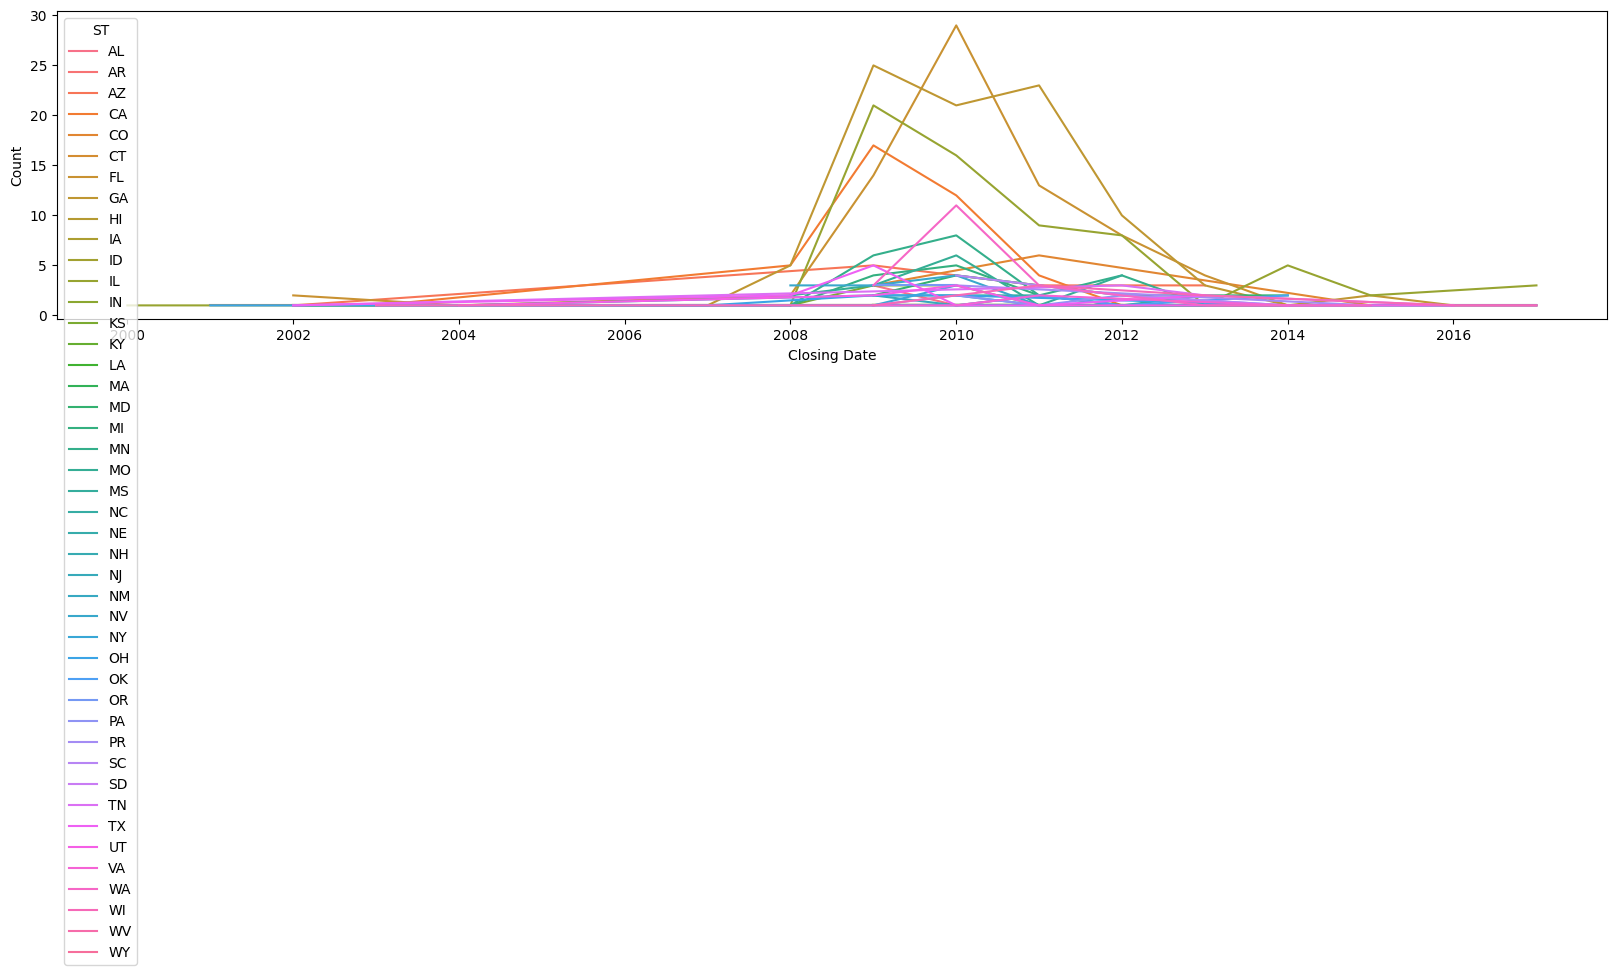

In [66]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=by_st_year, x='Closing Date', y='Count', hue='ST')
plt.show()

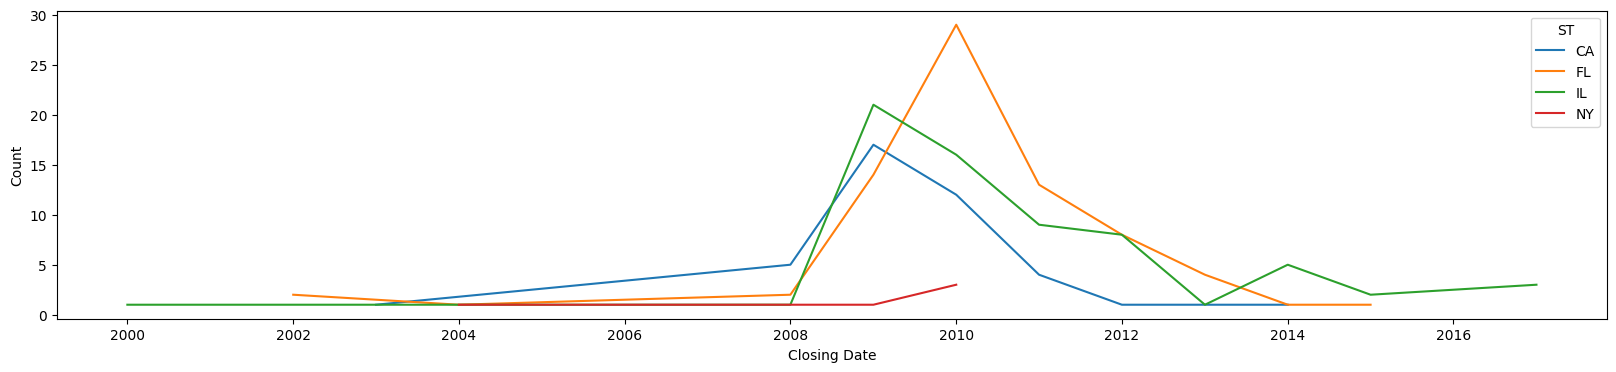

In [67]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=by_st_year[by_st_year.ST.isin(['CA', 'FL', 'IL', 'NY'])],
             x='Closing Date', y='Count', hue='ST')
plt.show()